Train: 25000 Test: 25000
Avg length: 238


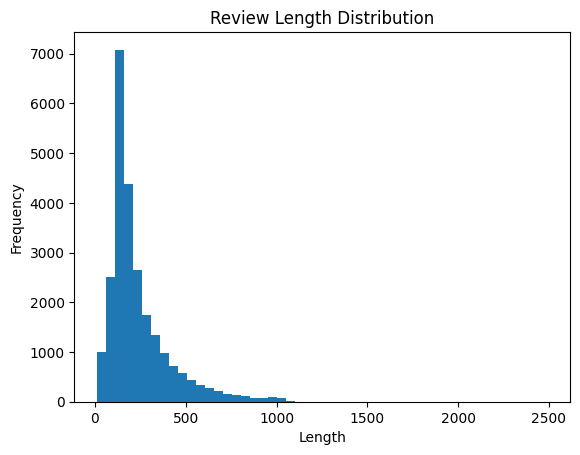

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.7443 - loss: 0.5037 - val_accuracy: 0.8620 - val_loss: 0.3250
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9059 - loss: 0.2348 - val_accuracy: 0.8942 - val_loss: 0.2643
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9700 - loss: 0.0968 - val_accuracy: 0.8906 - val_loss: 0.2842


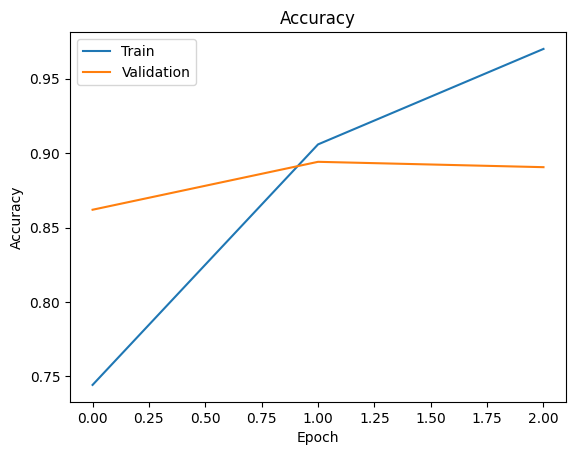

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8855 - loss: 0.2910

Final Accuracy: 88.55 %


In [3]:
# ==========================================
# IMDb Sentiment Analysis (FAST + 90% ACC)
# ==========================================

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------
# Load Dataset
# ------------------------------------------
vocab_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

# ------------------------------------------
# Basic EDA
# ------------------------------------------
review_lengths = [len(i) for i in x_train]

print("Train:", len(x_train), "Test:", len(x_test))
print("Avg length:", int(np.mean(review_lengths)))

plt.figure()
plt.hist(review_lengths, bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

# ------------------------------------------
# Preprocessing
# ------------------------------------------
max_len = 200
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

# ------------------------------------------
# CNN Model (FASTER + ACCURATE)
# ------------------------------------------
model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

# ------------------------------------------
# Compile (Adam Optimizer)
# ------------------------------------------
model.compile(
    optimizer='adam',   # ✅ Adam used
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ------------------------------------------
# Train
# ------------------------------------------
history = model.fit(
    x_train,
    y_train,
    epochs=3,          # fast + enough
    batch_size=128,
    validation_split=0.2
)

# ------------------------------------------
# Accuracy Graph
# ------------------------------------------
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

# ------------------------------------------
# Evaluate
# ------------------------------------------
loss, acc = model.evaluate(x_test, y_test)

print("\nFinal Accuracy:", round(acc * 100, 2), "%")